In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

In [ ]:
# Load dataset.csv
df = pd.read_csv('dataset.csv')

# Display first 10 rows
print("First 10 rows:")
print(df.head(10))

First 10 rows:
   Unnamed: 0                track_id                               artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV                           Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A                          Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b                Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx                          Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K                      Chord Overstreet   
5           5  01MVOl9KtVTNfFiBU9I7dc                          Tyrone Wells   
6           6  6Vc5wAMmXdKIAM7WUoEb7N  A Great Big World;Christina Aguilera   
7           7  1EzrEOXmMH3G43AXT1y7pA                            Jason Mraz   
8           8  0IktbUcnAGrvD03AWnz3Q8             Jason Mraz;Colbie Caillat   
9           9  7k9GuJYLp2AzqokyEdwEw2                        Ross Copperman   

                                          album_name  \
0                                             Comedy   
1  

In [ ]:
# Display shape
print("Shape of dataset:", df.shape)

Shape of dataset: (114000, 21)


In [ ]:
# Display data types
print("Data types:")
print(df.dtypes)

Data types:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [ ]:
# Display summary statistics
print("Summary statistics:")
print(df.describe())

Summary statistics:
          Unnamed: 0     popularity   duration_ms   danceability  \
count  114000.000000  114000.000000  1.140000e+05  114000.000000   
mean    56999.500000      33.238535  2.280292e+05       0.566800   
std     32909.109681      22.305078  1.072977e+05       0.173542   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%     28499.750000      17.000000  1.740660e+05       0.456000   
50%     56999.500000      35.000000  2.129060e+05       0.580000   
75%     85499.250000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.641383       5.309140      -8.258960       0.637553   
std         0.251529       3.559987       5.029337       0.480709   
min         0.000000       0.000000     -49.531000       0.000000   
25%         0.472000  

In [ ]:
# Drop unnecessary columns
cols_to_drop = ['track_id', 'artists', 'album_name', 'track_name']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

In [ ]:
# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
Unnamed: 0          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [ ]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# Drop duplicates
df = df.drop_duplicates()

In [ ]:
# Handle missing values: drop rows with any missing values
df = df.dropna()

In [ ]:
print("Shape after dropping duplicates and missing values:", df.shape)
print("\n" + "="*50 + "\n")

Shape after dropping duplicates and missing values: (114000, 17)




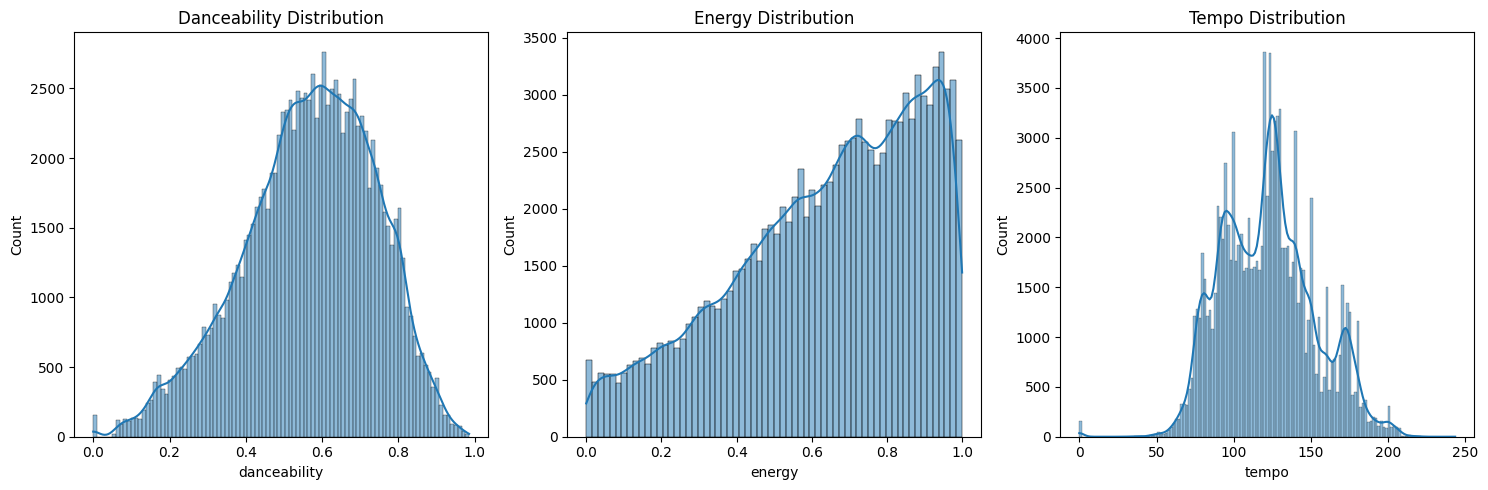

In [ ]:
# Plot histograms for danceability, energy, and tempo
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['danceability'], kde=True)
plt.title('Danceability Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['energy'], kde=True)
plt.title('Energy Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['tempo'], kde=True)
plt.title('Tempo Distribution')
plt.tight_layout()
plt.show()

<ipython-input-13-6ed95a41f66e>:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='popularity', y='energy', data=df, ci=None)


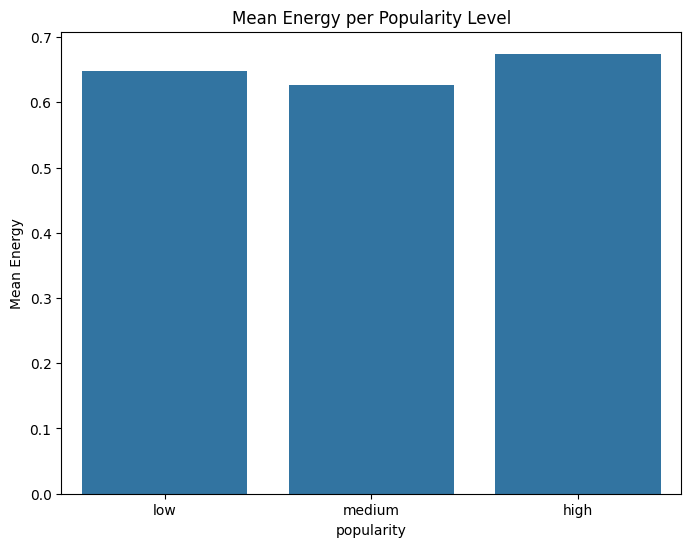

In [ ]:
# Create popularity column
df['popularity'] = pd.cut(df['popularity'], bins=[-np.inf, 40, 70, np.inf], labels=['low', 'medium', 'high'])

# Plot bar chart showing mean energy per popularity group
plt.figure(figsize=(8, 6))
sns.barplot(x='popularity', y='energy', data=df, ci=None)
plt.title('Mean Energy per Popularity Level')
plt.ylabel('Mean Energy')
plt.show()

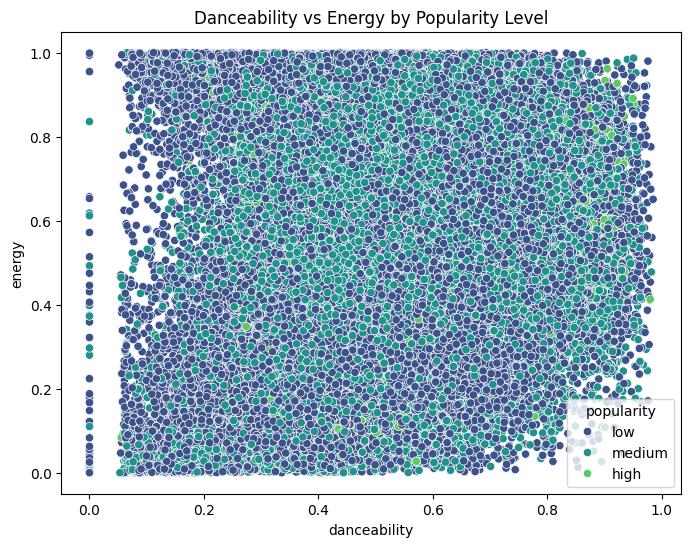

In [ ]:
# Plot scatter plot of danceability vs energy, coloured by popularity
plt.figure(figsize=(8, 6))
sns.scatterplot(x='danceability', y='energy', hue='popularity', data=df, palette='viridis')
plt.title('Danceability vs Energy by Popularity Level')
plt.show()

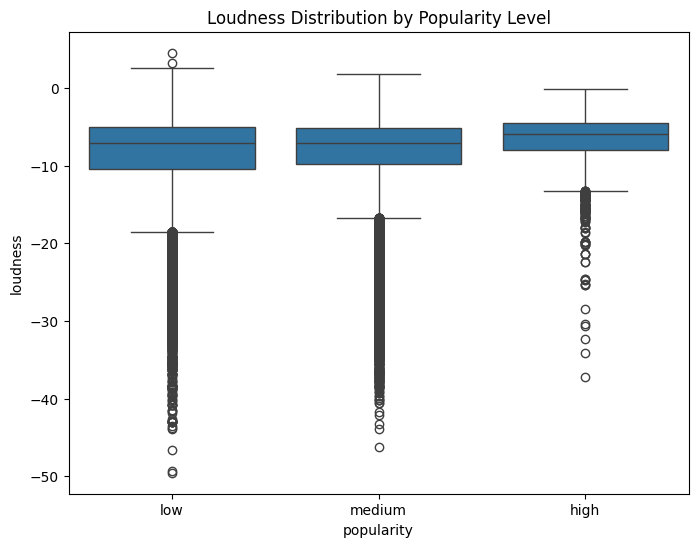

In [ ]:
# Plot box plot comparing loudness across popularity groups
plt.figure(figsize=(8, 6))
sns.boxplot(x='popularity', y='loudness', data=df)
plt.title('Loudness Distribution by Popularity Level')
plt.show()

In [ ]:
# Plot correlation heatmap (lower triangle only, annotated) for all numeric features
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

In [ ]:
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

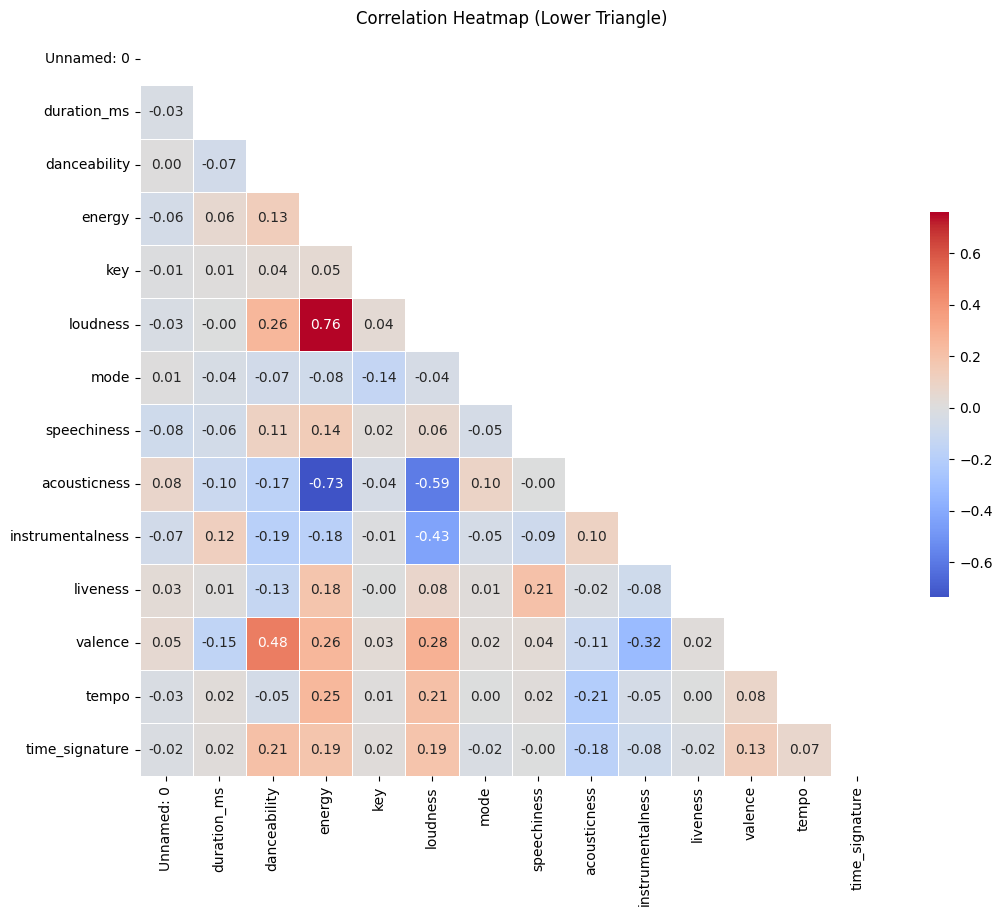

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap (Lower Triangle)')
plt.show()

In [ ]:
# Identify the strongest correlated pair (excluding self-correlation)
# We'll find the maximum absolute correlation in the upper triangle (lower triangle? Actually we masked upper, so we look at lower triangle without diagonal)
# Compute the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Take absolute values
abs_corr = corr_matrix.abs()

# Ignore self-correlation
np.fill_diagonal(abs_corr.values, 0)

# Get the maximum absolute correlation
max_corr = abs_corr.max().max()

In [ ]:
# Get the indices of the maximum correlation
i, j = np.where(abs_corr == max_corr)
# If multiple, take the first pair

In [ ]:
if len(i) > 0:
    row, col = i[0], j[0]
    var1, var2 = corr_matrix.columns[row], corr_matrix.columns[col]
    corr_value = corr_matrix.iloc[row, col]
    print(f"Strongest correlation: {var1} and {var2} = {corr_value:.4f}")
else:
    print("No correlation found.")

Strongest correlation: energy and loudness = 0.7617


In [ ]:
# Apply Label Encoding to explicit column (True/False)
if 'explicit' in df.columns:
    le = LabelEncoder()
    df['explicit_encoded'] = le.fit_transform(df['explicit'].astype(str))
else:
    print("Column 'explicit' not found.")
    # Create a dummy column if not present
    df['explicit_encoded'] = 0

In [ ]:
# Apply One-Hot Encoding with drop_first=True
if 'popularity' in df.columns:
    ohe = OneHotEncoder(drop='first', sparse_output=False)

    popularity_encoded = ohe.fit_transform(df[['popularity']])

    popularity_encoded_df = pd.DataFrame(
        popularity_encoded,
        columns=ohe.get_feature_names_out(['popularity']),
        index=df.index
    )

    df = pd.concat([df, popularity_encoded_df], axis=1)
else:
    print("Column 'popularity' not found.")

In [ ]:
# Create two new ratio features
df['energy_dance_ratio'] = df['energy'] / (df['danceability'] + 1e-6)
df['acousticness_energy_ratio'] = df['acousticness'] / (df['energy'] + 1e-6)

In [ ]:
# Bin tempo into 3 equal-width categories using pd.cut() with labels slow, medium, fast
df['tempo_bin'] = pd.cut(df['tempo'], bins=3, labels=['slow', 'medium', 'fast'])
print("Count per tempo bin:")
print(df['tempo_bin'].value_counts().sort_index())
print("\n" + "="*50 + "\n")

Count per tempo bin:
tempo_bin
slow       9149
medium    91876
fast      12975
Name: count, dtype: int64




In [ ]:
# Compute the absolute correlation matrix
# We'll consider only numeric columns for correlation (including the new encoded and ratio features)
# But note: we have added categorical encoded columns (explicit_encoded, popularity_encoded_*) which are numeric (0/1)
# We'll select all numeric columns again
numeric_cols_after = df.select_dtypes(include=[np.number]).columns
corr_matrix_abs = df[numeric_cols_after].corr().abs()

In [ ]:
# We want to find pairs with correlation > 0.85 (excluding self-correlation and duplicates)
# We'll create a mask for the upper triangle without diagonal
upper_tri = np.triu(np.ones_like(corr_matrix_abs, dtype=bool), k=1)
high_corr_pairs = []
for i in range(len(corr_matrix_abs.columns)):
    for j in range(i+1, len(corr_matrix_abs.columns)):
        if corr_matrix_abs.iloc[i, j] > 0.85:
            high_corr_pairs.append((corr_matrix_abs.columns[i], corr_matrix_abs.columns[j], corr_matrix_abs.iloc[i, j]))

In [ ]:
if high_corr_pairs:
    print("Features with correlation > 0.85:")
    for var1, var2, corr in high_corr_pairs:
        print(f"{var1} & {var2}: {corr:.4f}")
else:
    print("No feature pairs with correlation > 0.85.")

Features with correlation > 0.85:
popularity_low & popularity_medium: 0.9143


In [ ]:
# Standardise all numeric features using StandardScaler
scaler = StandardScaler()
numeric_data = df[numeric_cols_after]
scaled_data = scaler.fit_transform(numeric_data)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols_after)

print("Dataset dimensions before scaling:", numeric_data.shape)
print("Dataset dimensions after scaling:", scaled_df.shape)
print("\n" + "="*50 + "\n")

Dataset dimensions before scaling: (114000, 19)
Dataset dimensions after scaling: (114000, 19)




In [ ]:
# Apply PCA with 5 components
pca = PCA(n_components=5)

# Fit PCA and transform the data
pca_result = pca.fit_transform(scaled_df)

# Convert to DataFrame
pca_df = pd.DataFrame(
    pca_result,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())
print("Dataset dimensions before PCA:", scaled_df.shape)
print("Dataset dimensions after PCA:", pca_df.shape)

Explained variance ratio: [0.15855056 0.10281098 0.08204297 0.07291322 0.06502753]
Total explained variance: 0.48134525489768076
Dataset dimensions before PCA: (114000, 19)
Dataset dimensions after PCA: (114000, 5)
